Імпорти

In [20]:
import matplotlib.pyplot as plt
import numpy as np

Завантаження даних

In [18]:
train_data = np.genfromtxt(
    "lab_1_train.csv",
    delimiter=",",
    names=True,
    usecols=("x", "y")
)

test_data = np.genfromtxt(
    "lab_1_test.csv",
    delimiter=",",
    names=True,
    usecols=("x", "y")
)

x_train = train_data["x"]
y_train = train_data["y"]

x_test = test_data["x"]
y_test = test_data["y"]

print("Train size:", len(x_train))
print("Test size:", len(x_test))

Train size: 60
Test size: 40


Візуалізація даних 

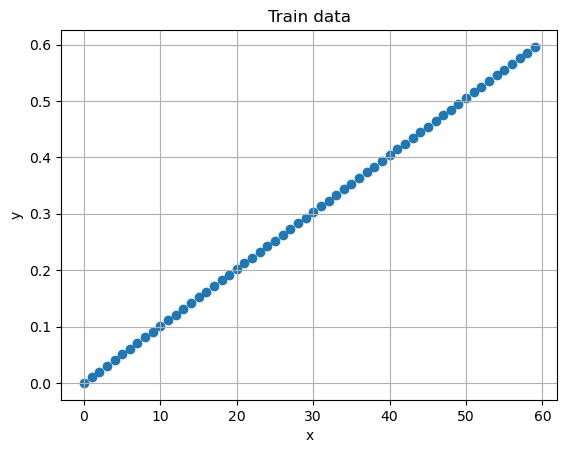

In [23]:
plt.scatter(x_train, y_train)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train data")

plt.grid()
plt.show()

Функція передбачення

In [34]:
def predict(x, w0, w1):
    return w0 + w1 * x

Середньоквадратична помилка

In [31]:
def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

Градієнтний спуск

In [71]:
def gradient_descent(x, y, learning_rate, max_epochs, epsilon):
    w0 = 0.0
    w1 = 0.0

    n = len(x)

    previous_loss = 0

    for epoch in range(max_epochs):
        y_pred = predict(x, w0, w1)

        error = y_pred - y

        loss = mse(y, y_pred)

        dw0 = (2 / n) * np.sum(error)
        dw1 = (2 / n) * np.sum(error * x)

        w0 = w0 - learning_rate * dw0
        w1 = w1 - learning_rate * dw1

        print(
            f"Епоха: {epoch + 1}, "
            f"w0: {w0:.6f}, "
            f"w1: {w1:.6f}, "
            f"MSE: {loss:.6f}"
        )

        if abs(previous_loss - loss) < epsilon:
            print()
            print("Градієнтний спуск зійшовся")
            print("Епоха:", epoch + 1)
            break

        previous_loss = loss

    return w0, w1

Навчання

In [72]:
w0, w1 = gradient_descent(x_train, y_train, learning_rate = 0.0001, max_epochs = 100, epsilon = 1e-9)
print()
print("Остаточні ваги:")
print("w0 =", w0)
print("w1 =", w1)
print(f"y = {w0:.6f} + {w1:.6f} * x")

Епоха: 1, w0: 0.000060, w1: 0.002364, MSE: 0.119393
Епоха: 2, w0: 0.000105, w1: 0.004174, MSE: 0.070021
Епоха: 3, w0: 0.000140, w1: 0.005561, MSE: 0.041066
Епоха: 4, w0: 0.000167, w1: 0.006623, MSE: 0.024084
Епоха: 5, w0: 0.000187, w1: 0.007436, MSE: 0.014125
Епоха: 6, w0: 0.000203, w1: 0.008058, MSE: 0.008284
Епоха: 7, w0: 0.000215, w1: 0.008535, MSE: 0.004858
Епоха: 8, w0: 0.000224, w1: 0.008900, MSE: 0.002849
Епоха: 9, w0: 0.000231, w1: 0.009180, MSE: 0.001671
Епоха: 10, w0: 0.000237, w1: 0.009394, MSE: 0.000980
Епоха: 11, w0: 0.000241, w1: 0.009558, MSE: 0.000575
Епоха: 12, w0: 0.000244, w1: 0.009684, MSE: 0.000337
Епоха: 13, w0: 0.000246, w1: 0.009780, MSE: 0.000198
Епоха: 14, w0: 0.000248, w1: 0.009854, MSE: 0.000116
Епоха: 15, w0: 0.000250, w1: 0.009910, MSE: 0.000068
Епоха: 16, w0: 0.000251, w1: 0.009953, MSE: 0.000040
Епоха: 17, w0: 0.000252, w1: 0.009986, MSE: 0.000023
Епоха: 18, w0: 0.000252, w1: 0.010012, MSE: 0.000014
Епоха: 19, w0: 0.000253, w1: 0.010031, MSE: 0.000008
Еп

Перевірка моделі на тестових даних

In [63]:
test_predictions = predict(x_test, w0, w1)

test_loss = mse(y_test, test_predictions)

print("Test MSE:", test_loss)

Test MSE: 0.36716903751871344


Візуалізація результатів лінійної регресії

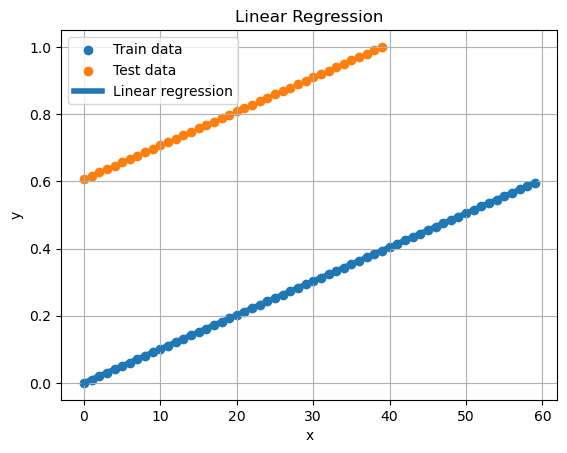

In [79]:
plt.scatter(
    x_train,
    y_train,
    label="Train data"
)

plt.scatter(
    x_test,
    y_test,
    label="Test data"
)

x_min = min(np.min(x_train), np.min(x_test))
x_max = max(np.max(x_train), np.max(x_test))

x_line = np.linspace(x_min, x_max, 100)

y_line = predict(x_line, w0, w1)

plt.plot(
    x_line,
    y_line,
    label="Linear regression",
    linewidth=4,
    zorder=4
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")

plt.legend()
plt.grid()

plt.show()